# Job Hunting Agent using ReAct

### Import Modules

In [1]:
from dotenv import load_dotenv
import os
import docx
import pdfplumber
import subprocess
from openai import OpenAI

### Add OPENAI_API_KEY to Environment Variable

In [2]:
# Please make sure to create a .env file in the root directory of the project and add your OpenAI API key as follows:
# OPENAI_API_KEY="<your_openai_api_key_here>"

# Please make sure to create a .env file in the root directory of the project and add your LangSmith API key as follows:
# LANGCHAIN_API_KEY="<your_langsmith_api_key_here>"
# LANGSMITH_API_KEY="<your_langsmith_api_key_here>"
# LANGSMITH_TRACING=<true_or_false>
# LANGCHAIN_TRACING_V2=<true_or_false>
# LANGSMITH_ENDPOINT="<your_langsmith_endpoint_here>" (if using a custom endpoint, otherwise it defaults to https://api.smith.langchain.com)
# LANGSMITH_PROJECT="<your_agent_name_here>"

load_dotenv()


True

## Build File Reader Tool to Extract CV / Resume Text

In [3]:
def extract_cv_text(file_path: str) -> str:
    
    ext = os.path.splitext(file_path)[-1].lower()
    
    if '.docx' in ext:
        
        try:
            
            doc = docx.Document(file_path)
            
            text = [para.text for para in doc.paragraphs]
            
            return '\n'.join(text)
        
        except Exception as e:
            
            return f"Error reading .doc file: {e}"
        
    elif '.pdf' in ext:
        
        try:
            text = []
            
            with pdfplumber.open(file_path) as pdf:
                
                for page in pdf.pages:
                    page_text = page.extract_text()
                    
                    if page_text:
                        text.append(page_text)
                    
            
            return '/n'.join(text)
        
        except Exception as e:
            
            return f"Error reading .pdf file: {e}"
    
    elif '.doc' in ext:
        
        
        try:
            
            temp_docx = file_path + '.temp.docx'
            
            subprocess.run(['soffice', '--headless', '--convert-to', 'docx', '--outdir', os.path.dirname(file_path), file_path], check=True)
            
            doc = docx.Document(temp_docx)
            
            text = [para.text for para in text.paragraphs]
            
            return '\n'.join(text)
        
        except Exception as e:
            
            return f"Error reading .doc file: {e}"
            
        
    else:
        
        return "Unsupported file format. Please upload a .doc, .docx, or .pdf file."        
            
                

In [4]:
file_path = "data/cv_sample.pdf"
    
cv_text = extract_cv_text(file_path)

print(cv_text)

Curriculum Vitae
Maxime Muster
M.Muster@email.de | Phone: 0123 4567890
This Example Curriculum Vitae (CV) illustrates how prior experience is typically displayed in
a German Academic CV.
The CV serves as an opportunity for the applicant to highlight any past or current activities
that may be relevant to determine their qualification as PhD student or otherwise interesting
to the selection committee.
Sections that might not apply to all applicants are marked here with a green ‘optional’ label.
Please do not include this label in your own CV. Please remove sections that do not apply to
you, or add sections as you need.
Education
2018 - today M.Sc. Psychology at University, City, Country
§ Current average of 1,3 (very good)
§ Major in Cognitive Neuropsychology, Minor in Clinical Psychology
9/2019 - 12/2019 Exchange Semester at Foreign University, City, Country
§ Focus on Cognitive Sciences
2014 - 2018 B.Sc. Psychology at University, City, Country
§ Graduated with an average of 1,6 (very g

## Building Web Search API Tool to crawl for job posting online

In [5]:
client = OpenAI(api_key = os.getenv("OPENAI_API_KEY"))

In [6]:
job_link = "https://www.linkedin.com/jobs/view/4402161329"

In [7]:
completion = client.chat.completions.create(
    model = "gpt-4o-search-preview",
    web_search_options = {
        "search_context_size": "medium"
    },
    messages = [
        {
            "role": "system",
            "content": """
            You are a helpful tool that visits the following job posting and carefully reads its content.
            Visit the provided link and summarize the key details in a clear and concise format, including:
            - Job Title
            - Company Name
            - Location
            - Job Description
            - Employment Type (e.g., Full-time, Part-time, Contract)
            - Required Qualifications
            - Preferred Qualifications
            - Application Instructions
            - Salary Range (if listed)
            - Primary Responsibilities
            - Benefits (if listed)
            - Posting Date (if available)
            - Any other relevant information that would help a job seeker understand the role and how to apply
            
            Format:
            - Respond with a clear and structured bullet point list
            - Use exact factual information from the posting, no rewording beyond make it concise.
            - If the posting is missing, inaccessible or contains no job details, respond with "Job posting unavailable or contains no job details."
            
            Do's:
            - Do visit the provided link and read the job posting carefully.
            - Ensure all extracted details are accurate and directly taken from the posting.
            - Keep descriptions concise while retaining all critical information, short, professional and easy to scan.
            - Use consistent formatting for all fields (e.g. "Job Title: ...")
            
            Dont's:
            - Do not include any information that is not explicitly stated in the job posting.
            - Do not make assumptions or add interpretations beyond what is provided in the posting.
            - Do not include filler language, speculation or personal opinions.
            - Do not rewrite or interpret details-only report factual information from the posting. 
            """
        },
        {
            "role": "user",
            "content": f"Visit this job posting link and extract details: \n {job_link}"
        }
    ]
)

In [8]:
print(completion.choices[0].message.content)

- **Job Title:** Sr. Digital Analyst – Tesla Energy EMEA (m/w/d)
- **Company Name:** Tesla
- **Location:** Berlin, Berlin, Germany
- **Employment Type:** Full-time
- **Job Description:**
  - Collaborate across Demand Generation, Marketing, Web Development, Software, and executive teams to optimize the Web and Digital Customer Experience for Tesla Energy in Europe.
  - Lead web analytics to enhance customer conversion and interaction.
  - Design and conduct A/B tests on web pages to evaluate performance and drive improvements.
  - Analyze web traffic data to recommend UX enhancements and ensure tagging/tracking compliance.
  - Combine marketing channel data with CRM insights for audience sizing and campaign optimization.
  - Deploy dashboards and conduct impact analysis of business process changes on customer experience.
  - Understand multi-channel marketing campaigns and develop explanatory performance models.
- **Required Qualifications:**
  - Relevant enterprise-level experience in 

## Building ReAct Agent

### Integrate CV Reader Tool and Web Search Tool into the Agent

In [9]:
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode

In [10]:
llm_model = ChatOpenAI(
                            model = "gpt-5.4-mini"
                        )

In [11]:
@tool
def extract_cv_text(file_path: str) -> str:
    """
    Extract text content from a CV/resume file.
    
    Supports .docx, .pdf, and .doc formats. For .doc files, 
    LibreOffice (soffice) is used to convert to .docx first.
    
    Args:
        file_path: Path to the CV/resume file (.docx, .pdf, or .doc).
    
    Returns:
        str: Extracted text content from the file, or an error message if reading fails.
    """
    
    ext = os.path.splitext(file_path)[-1].lower()
    
    if '.docx' in ext:
        
        try:
            
            doc = docx.Document(file_path)
            
            text = [para.text for para in doc.paragraphs]
            
            return '\n'.join(text)
        
        except Exception as e:
            
            return f"Error reading .doc file: {e}"
        
    elif '.pdf' in ext:
        
        try:
            text = []
            
            with pdfplumber.open(file_path) as pdf:
                
                for page in pdf.pages:
                    page_text = page.extract_text()
                    
                    if page_text:
                        text.append(page_text)
                    
            
            return '/n'.join(text)
        
        except Exception as e:
            
            return f"Error reading .pdf file: {e}"
    
    elif '.doc' in ext:
        
        
        try:
            
            temp_docx = file_path + '.temp.docx'
            
            subprocess.run(['soffice', '--headless', '--convert-to', 'docx', '--outdir', os.path.dirname(file_path), file_path], check=True)
            
            doc = docx.Document(temp_docx)
            
            text = [para.text for para in text.paragraphs]
            
            return '\n'.join(text)
        
        except Exception as e:
            
            return f"Error reading .doc file: {e}"
            
        
    else:
        
        return "Unsupported file format. Please upload a .doc, .docx, or .pdf file."

In [12]:
@tool
def job_posting_scraper(job_link: str) -> str:
    """
    Scrape job posting details from a given URL.
    
    Args:
        job_link: URL of the job posting to scrape.
    
    Returns:
        str: A structured summary of the job posting details, or an error message if scraping fails.
    """
    
    completion = client.chat.completions.create(
                            model = "gpt-4o-search-preview",
                            web_search_options = {
                                "search_context_size": "medium"
                            },
                            messages = [
                                {
                                    "role": "system",
                                    "content": """
                                    You are a helpful tool that visits the following job posting and carefully reads its content.
                                    Visit the provided link and summarize the key details in a clear and concise format, including:
                                    - Job Title
                                    - Company Name
                                    - Location
                                    - Job Description
                                    - Employment Type (e.g., Full-time, Part-time, Contract)
                                    - Required Qualifications
                                    - Preferred Qualifications
                                    - Application Instructions
                                    - Salary Range (if listed)
                                    - Primary Responsibilities
                                    - Benefits (if listed)
                                    - Posting Date (if available)
                                    - Any other relevant information that would help a job seeker understand the role and how to apply
                                    
                                    Format:
                                    - Respond with a clear and structured bullet point list
                                    - Use exact factual information from the posting, no rewording beyond make it concise.
                                    - If the posting is missing, inaccessible or contains no job details, respond with "Job posting unavailable or contains no job details."
                                    
                                    Do's:
                                    - Do visit the provided link and read the job posting carefully.
                                    - Ensure all extracted details are accurate and directly taken from the posting.
                                    - Keep descriptions concise while retaining all critical information, short, professional and easy to scan.
                                    - Use consistent formatting for all fields (e.g. "Job Title: ...")
                                    
                                    Dont's:
                                    - Do not include any information that is not explicitly stated in the job posting.
                                    - Do not make assumptions or add interpretations beyond what is provided in the posting.
                                    - Do not include filler language, speculation or personal opinions.
                                    - Do not rewrite or interpret details-only report factual information from the posting. 
                                    """
                                },
                                {
                                    "role": "user",
                                    "content": f"Visit this job posting link and extract details: \n {job_link}"
                                }
                            ]
                        )
    
    return completion.choices[0].message.content

In [13]:
tools = [extract_cv_text, job_posting_scraper]
tools_node = ToolNode(tools = tools)

In [14]:
job_hunting_agent = llm_model.bind_tools(tools = tools)

### Create Assistant Node

In [15]:
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
from langgraph.graph import MessagesState, START, END, StateGraph
from langgraph.prebuilt import tools_condition
from langsmith import traceable
from IPython.display import Image, display

In [ ]:
sys_msg = SystemMessage(content="""
You are an expert career assistant that helps the user with questions related to jobs, careers, and applications.

Your key capabilities:
- You have access to the user's CV and can read its contents using the `extract_cv_text` tool.
- You can look up and extract details from job postings using the `job_posting_scraper`.
- You can compare the user's CV against one or more job postings to determine suitability and provide tailored advice.
- You can suggest improvements to the CV for better alignment with target roles.

When answering:
1. First, think step-by-step about the user's request.
2. If the task requires reading the CV, call the CV extraction tool before answering.
3. If the task involves evaluating job postings, call the job posting tool to gather accurate information before answering.
4. Compare and reason about the information before providing your final response.

Response format:
- Be clear, concise, and structured with bullet points or numbered lists.
- Use section headers when possible (e.g., "Strengths", "Weaknesses", "Recommendations").
- Support your statements with evidence from the CV or job postings.
- Avoid vague language—be specific and factual.

Constraints:
- Do not invent or guess details about the user's experience or job postings.
- Only use information available in the CV, job postings, or provided context.
- Keep your tone professional, friendly, and supportive.


""")

In [17]:
@traceable(name = os.getenv("LANGSMITH_PROJECT"))
def assistant(state: MessagesState):
    return MessagesState(messages = [job_hunting_agent.invoke([sys_msg] + state["messages"])])

### Building Graph

In [18]:
agent_graph = StateGraph(MessagesState)

In [19]:
agent_graph.add_node("assistant", assistant)
agent_graph.add_node("tools", tools_node)

In [20]:
agent_graph.add_edge(START, "assistant")
agent_graph.add_conditional_edges(source = "assistant",
                                  path = tools_condition)
agent_graph.add_edge("tools", "assistant")

In [21]:
agent_graph_runnable = agent_graph.compile()


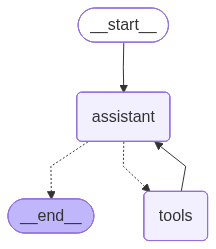

In [22]:
agent_graph_runnable

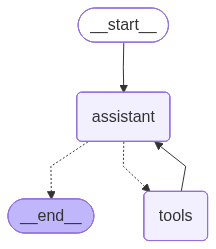

In [23]:
display(Image(agent_graph_runnable.get_graph(xray=True).draw_mermaid_png()))

### Testing Agent Graph

In [24]:
messages = [
    HumanMessage(content="""
                 
                 Can you take a look at my CV at the location "data/cv_sample.pdf" and tell me how well it matches the requirements for the following jobs: 
                 
                 https://www.linkedin.com/jobs/view/4402161329
                 https://www.linkedin.com/jobs/view/4409462037
                 https://www.linkedin.com/jobs/view/4343051642
                 
                 
                 Tell me which one is the most suitable for my experience and skills, and what improvements I can make to my CV to increase my chances of getting an interview for that job.
                 
                 """)
]

In [25]:
result = agent_graph_runnable.invoke(MessagesState(messages = messages))

In [26]:
result["messages"][-1].pretty_print()

================================== Ai Message ==================================

Here’s a clear comparison of your CV against the three roles, plus which one looks most suitable and how to improve your CV for that target.

## Quick summary

Your CV is strongest for **research/academic data analysis** and **basic quantitative work**:
- Psychology background
- Research internships / assistant experience
- Data acquisition and analysis
- SPSS, Matlab, some R
- EEG / eye tracking
- Teaching statistics
- Strong English/German

It is **less aligned with enterprise digital analytics / marketing analytics** roles because it does **not show**:
- SQL
- GA4 / Google Tag Manager
- A/B testing in a commercial setting
- BigQuery
- BI tools like Tableau / Power BI / Looker Studio
- CRM / marketing data integration
- Web analytics or paid media analytics
- Client-facing consulting experience

---

## Match by job

### 1) Tesla — Sr. Digital Analyst – Tesla Energy EMEA
**Match level: Low to medium**



In [27]:
for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================



                 Can you take a look at my CV at the location "data/cv_sample.pdf" and tell me how well it matches the requirements for the following jobs: 

                 https://www.linkedin.com/jobs/view/4402161329
                 https://www.linkedin.com/jobs/view/4409462037
                 https://www.linkedin.com/jobs/view/4343051642


                 Tell me which one is the most suitable for my experience and skills, and what improvements I can make to my CV to increase my chances of getting an interview for that job.

                 
================================== Ai Message ==================================
Tool Calls:
  extract_cv_text (call_9nyYPOnTahWvtH4Me6GoEAVo)
 Call ID: call_9nyYPOnTahWvtH4Me6GoEAVo
  Args:
    file_path: data/cv_sample.pdf
  job_posting_scraper (call_1FawEGkxvtKHcFG7yirILfsN)
 Call ID: call_1FawEGkxvtKHcFG7yirILfsN
  Args:
    job_link: https://www.linked

### Adding Memory

In [28]:
from langgraph.checkpoint.memory import InMemorySaver

In [29]:
memory = InMemorySaver()

In [30]:
agent_graph_runnable_with_memory = agent_graph.compile(checkpointer = memory)


In [31]:
config = {"configurable": {
    "thread_id": "job_hunting_thread_1"
}}

In [32]:
result = agent_graph_runnable_with_memory.invoke(MessagesState(messages = messages), config = config)

In [33]:
for message in result["messages"]:
        message.pretty_print()

================================ Human Message =================================



                 Can you take a look at my CV at the location "data/cv_sample.pdf" and tell me how well it matches the requirements for the following jobs: 

                 https://www.linkedin.com/jobs/view/4402161329
                 https://www.linkedin.com/jobs/view/4409462037
                 https://www.linkedin.com/jobs/view/4343051642


                 Tell me which one is the most suitable for my experience and skills, and what improvements I can make to my CV to increase my chances of getting an interview for that job.

                 
================================== Ai Message ==================================
Tool Calls:
  extract_cv_text (call_4z63gbMj8FT00cxBNdF9opBO)
 Call ID: call_4z63gbMj8FT00cxBNdF9opBO
  Args:
    file_path: data/cv_sample.pdf
  job_posting_scraper (call_HDaJq9AHrrDxKzIKZIMTX2up)
 Call ID: call_HDaJq9AHrrDxKzIKZIMTX2up
  Args:
    job_link: https://www.linked

In [34]:
gap_analysis_message = [HumanMessage(content="""
                        Now that you have analyzed my CV against the job postings, can you provide a gap analysis for
                        the most suitable job, outlining the specific areas where my CV does not fully meet the job requirements and 
                        offering targeted recommendations for how I can improve my CV to better align with that role?
                        """)]

In [35]:
result = agent_graph_runnable_with_memory.invoke(MessagesState(messages = gap_analysis_message), config = config)

In [36]:
result["messages"][-1].pretty_print()

================================== Ai Message ==================================

## Gap analysis for the most suitable role: Amazon Advertising — Analytics and Insight Professional

Based on your CV, this is the **best-fit role** among the jobs you shared. Your profile is strong in **quantitative analysis, statistics, and research**, but the CV does not yet fully match the **commercial, client-facing, and business-insight-focused** nature of this role.

---

## 1) Where your CV matches the role

### Strong alignment
Your CV already shows:
- **Data analysis experience**
  - Research internship
  - Research assistant role
- **Statistical foundation**
  - Teaching a seminar on fundamental statistics
- **Analytical tools**
  - SPSS
  - Matlab
  - Some R
- **Communication skills**
  - Teaching experience
  - Conference poster presentation
- **International language ability**
  - German and English

These are relevant foundations for an analytics and insight role.

---

## 2) Key gaps vs. t